imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data collectons and processing


In [15]:
import os
os.listdir()

['.config', 'train.csv', 'sample_data']

In [4]:
from google.colab import files
uploaded=files.upload()

Saving train.csv to train.csv


In [5]:
train=pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.shape  #tell how many rows and columns eg:(889,20)
train.info()  #give full info
train.isnull().sum() #gives no of enteries have null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


clean dataset

In [7]:
#drop cabin from dataframe since it has high missing values
train=train.drop(columns="Cabin",axis=1)
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [8]:
train['Age']=train['Age'].fillna(train["Age"].median())

In [9]:
train['Embarked'].fillna(train['Embarked'].mode()[0],inplace=True)  #mode cause mean dos not work here as it is not numerical

/tmp/ipykernel_3727/3834936006.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0],inplace=True)  #mode cause mean dos not work here as it is not numerical


In [10]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


convert categorical i.e string texts into numbers

In [11]:
train["Sex"].unique()
train["Sex"]=train["Sex"].map({"male":0,"female":1})
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


for embarked lets remove the categorical to numerical.for this use get_dummies.

In [12]:
train=pd.get_dummies(train,columns=["Embarked"],drop_first=True)
  #drop first to from the c val just to make things ec that is embarked has three values c,q,s drop see lets handle with 2 values

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


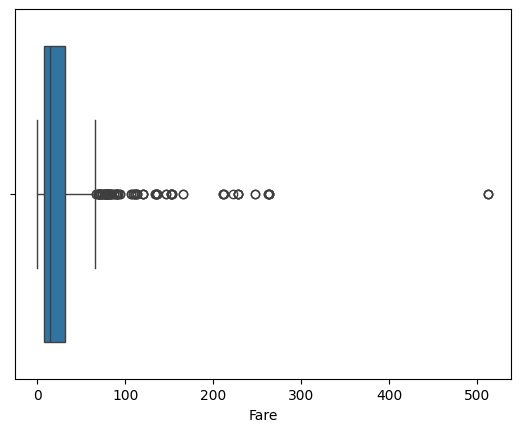

In [13]:
sns.boxplot(x=train["Fare"])
plt.show()

In [16]:
sns.set()

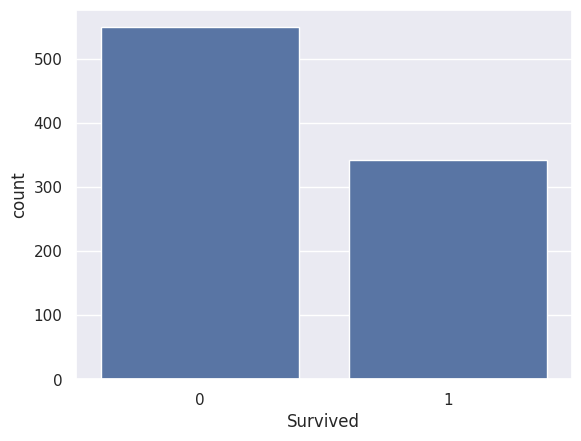

In [20]:
sns.countplot(x='Survived', data=train)
plt.show()

In [21]:
Q1 = train["Fare"].quantile(0.25)


In [22]:
Q3 = train["Fare"].quantile(0.75)

In [23]:
IQR = Q3 - Q1

In [24]:
lower = Q1 - 1.5 * IQR

In [25]:
upper = Q3 + 1.5 * IQR

In [26]:
train = train[
    (train["Fare"] >= lower) &
    (train["Fare"] <= upper)
]

In [27]:
train.shape

(775, 12)

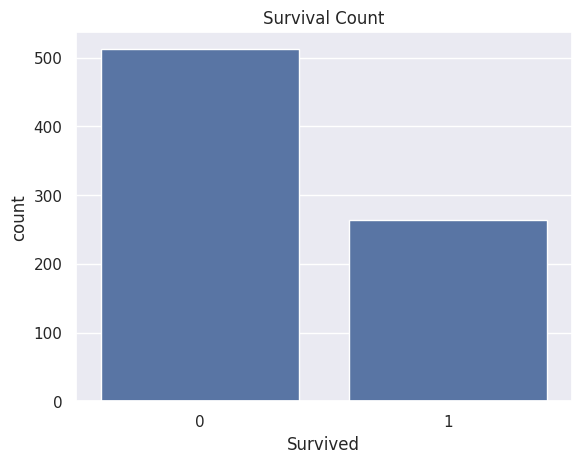

In [28]:
sns.countplot(x='Survived', data=train)
plt.title("Survival Count")
plt.show()

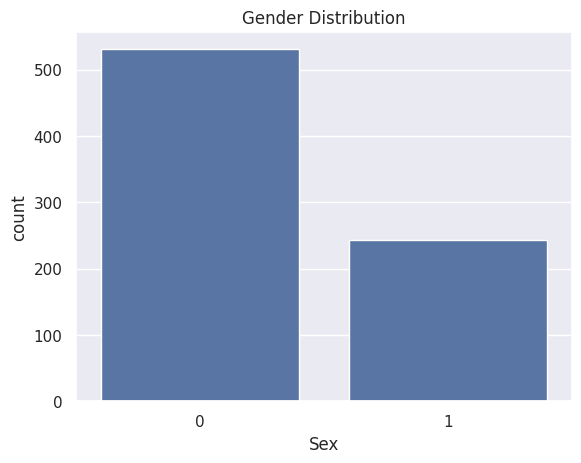

In [29]:
sns.countplot(x='Sex', data=train)
plt.title("Gender Distribution")
plt.show()

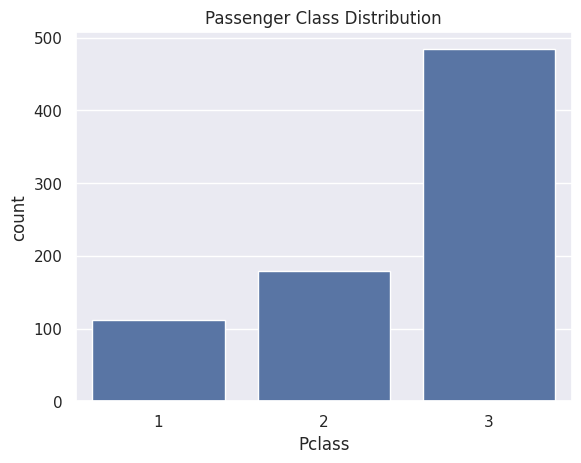

In [30]:
sns.countplot(x='Pclass', data=train)
plt.title("Passenger Class Distribution")
plt.show()

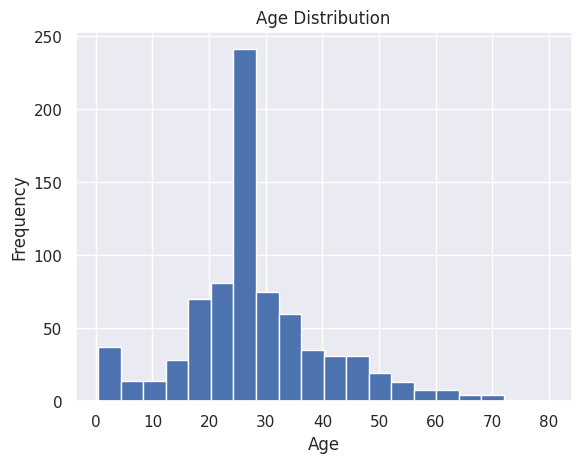

In [31]:
plt.hist(train["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

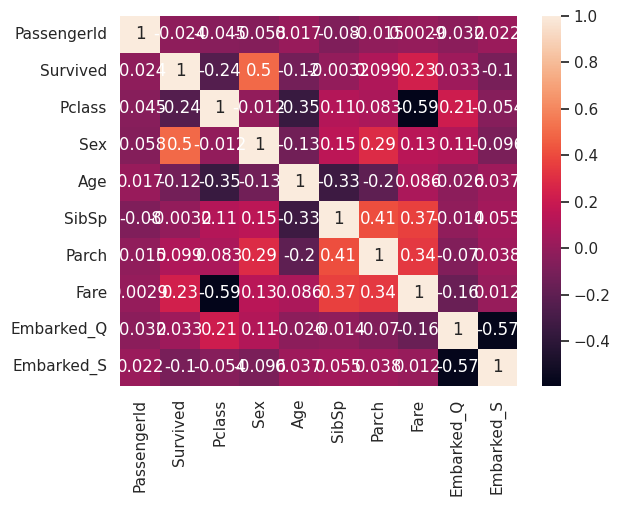

In [32]:
sns.heatmap(train.corr(numeric_only=True), annot=True)
plt.show()

In [33]:
train.to_csv("cleaned_titanic.csv", index=False)